# Práctica 4: Introducción a los Biopotenciales y Adquisición de Señales ECG y EMG

Bioseñales y Sistemas  
- Michael Salazar
- Juan Basante

**Facultad de Ingeniería – Bioingeniería**  

**Universidad de Antioquia**

---

## Objetivo General
Fundamentar los conceptos requeridos para la adquisición de señales biomédicas, particularmente las relacionadas con la actividad cardiovascular y muscular, mediante el uso del módulo SHIELD-EKG-EMG de Olimex y un Arduino UNO como conversor analógico-digital (ADC).

---

## Importaciones y Configuración General

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#Libreria especializadas en señales biomédicas 
import neurokit2 as nk   # Procesamiento de señales fisiológicas

# referencia: https://github.com/Aura-healthcare/hrv-analysis

def get_time_domain_features(rr_intervals):
    """
    Extrae características HRV en el dominio del tiempo a partir de
    una lista de intervalos RR en milisegundos.
    Replica la función get_time_domain_features de la librería hrvanalysis.
    """
    rr = np.array(rr_intervals, dtype=float)
    diff_rr = np.diff(rr)

    mean_nni   = np.mean(rr)
    sdnn       = np.std(rr, ddof=1)
    sdsd       = np.std(diff_rr, ddof=1)
    rmssd      = np.sqrt(np.mean(diff_rr ** 2))
    median_nni = np.median(rr)
    range_nni  = np.max(rr) - np.min(rr)
    nni_50     = int(np.sum(np.abs(diff_rr) > 50))
    pnni_50    = 100 * nni_50 / len(diff_rr)
    nni_20     = int(np.sum(np.abs(diff_rr) > 20))
    pnni_20    = 100 * nni_20 / len(diff_rr)
    cvsd       = rmssd / mean_nni
    cvnni      = sdnn / mean_nni
    hr         = 60000 / rr
    mean_hr    = np.mean(hr)
    max_hr     = np.max(hr)
    min_hr     = np.min(hr)
    std_hr     = np.std(hr, ddof=1)

    return {
        'mean_nni':   mean_nni,
        'sdnn':       sdnn,
        'sdsd':       sdsd,
        'nni_50':     nni_50,
        'pnni_50':    pnni_50,
        'nni_20':     nni_20,
        'pnni_20':    pnni_20,
        'rmssd':      rmssd,
        'median_nni': median_nni,
        'range_nni':  range_nni,
        'cvsd':       cvsd,
        'cvnni':      cvnni,
        'mean_hr':    mean_hr,
        'max_hr':     max_hr,
        'min_hr':     min_hr,
        'std_hr':     std_hr,
    }

# ── Parámetros de adquisición ─────────────────────────────────────────────────
FS = 100          # Frecuencia de muestreo en Hz
ADC_BITS = 10     # Resolución del ADC del Arduino UNO
V_REF = 5.0       # Voltaje de referencia del ADC en voltios

def adc_to_volts(adc_signal):
    """Convierte valores crudos del ADC (0–1023) a voltaje (0–5 V)."""
    return adc_signal * V_REF / (2**ADC_BITS - 1)

print(f"Parámetros: fs={FS} Hz | ADC {ADC_BITS} bits | V_ref={V_REF} V")

Parámetros: fs=100 Hz | ADC 10 bits | V_ref=5.0 V


## Carga de las Señales Adquiridas

In [3]:
# ── Lectura de los archivos CSV generados durante la práctica ─────────────────
# Cada CSV contiene dos columnas: tiempo_s (eje temporal) y EMG (valor ADC)

df_ecg        = pd.read_csv('señal_ECG.csv')
df_ecg_inv    = pd.read_csv('señal_ECG_contraria.csv')
df_emg_1p     = pd.read_csv('señal_EMG_1pulso.csv')
df_emg_2p     = pd.read_csv('señal_EMG2pulos.csv')

# ── Extracción de vectores de tiempo y señal (convertidos a voltios) ──────────
t_ecg   = df_ecg['tiempo_s'].values
ecg_v   = adc_to_volts(df_ecg['EMG'].values.astype(float))          # ECG normal

t_ecg_i = df_ecg_inv['tiempo_s'].values
ecg_i_v = adc_to_volts(df_ecg_inv['EMG'].values.astype(float))      # ECG con electrodos invertidos

t_emg1  = df_emg_1p['tiempo_s'].values
emg1_v  = adc_to_volts(df_emg_1p['EMG'].values.astype(float))       # EMG 1 contracción

t_emg2  = df_emg_2p['tiempo_s'].values
emg2_v  = adc_to_volts(df_emg_2p['EMG'].values.astype(float))       # EMG 2 contracciones

print("Señales cargadas:")
for nombre, sig in [("ECG normal", ecg_v), ("ECG invertida", ecg_i_v),
                    ("EMG 1 pulso", emg1_v), ("EMG 2 pulsos", emg2_v)]:
    print(f"  {nombre}: {len(sig)} muestras | min={sig.min():.3f} V | max={sig.max():.3f} V")

Señales cargadas:
  ECG normal: 1000 muestras | min=1.193 V | max=1.921 V
  ECG invertida: 1000 muestras | min=0.665 V | max=2.625 V
  EMG 1 pulso: 1000 muestras | min=0.391 V | max=2.410 V
  EMG 2 pulsos: 1000 muestras | min=0.543 V | max=2.576 V


---
## 5.1 Etapas del Registro de Biopotenciales

### Esquema conceptual

El registro de biopotenciales sigue una cadena de etapas bien definida, desde la fuente biológica hasta el almacenamiento digital. A continuación se describe cada etapa y se presenta un diagrama de bloques.

| N° | Etapa | Descripción |
|---|---|---|
| 1 | **Fuente biológica** | Generación del potencial de acción en membranas excitables (miocitos cardíacos, fibras musculares esqueléticas). La despolarización y repolarización iónica produce corrientes extracelulares detectables. |
| 2 | **Interfaz electrodo-piel** | Transducción de corriente iónica (electrolítica) a corriente electrónica mediante electrodos de superficie (Ag/AgCl). Es la etapa más crítica: determina la calidad del registro. Incluye preparación de la piel (abrasión, limpieza con alcohol). |
| 3 | **Amplificación diferencial** | El amplificador de instrumentación amplifica la diferencia entre dos electrodos (señal diferencial) y rechaza el ruido común (interferencia de red 60 Hz, movimiento, etc.). El SHIELD-EKG-EMG de Olimex integra esta etapa. |
| 4 | **Filtrado analógico** | Filtros pasa-banda integrados en el módulo: eliminan componentes de frecuencia fuera del rango de interés (ECG: 0.05–150 Hz; sEMG: 10–500 Hz). |
| 5 | **Conversión Analógico-Digital (ADC)** | El Arduino UNO digitaliza la señal analógica con un ADC de 10 bits y referencia de 5 V → resolución = 4.88 mV/LSB. La frecuencia de muestreo fue de 100 Hz (delay de 10 ms). |
| 6 | **Transmisión y almacenamiento** | Los datos se transfieren al PC vía comunicación serial (PySerial) y se almacenan en archivos CSV para posterior análisis. |
| 7 | **Procesamiento digital** | Filtrado digital adicional, detección de eventos (picos R), extracción de características (HRV, RMS del EMG), visualización e interpretación. |

### Componentes principales de un equipo de adquisición de biopotenciales

- **Electrodos**: Transductores electrodo-electrolito. Para señales de superficie se usan electrodos de Ag/AgCl desechables con gel conductor.
- **Amplificador de instrumentación**: Alta impedancia de entrada (>10 MΩ), alto CMRR (>80 dB), bajo ruido.
- **Filtros**: Pasa-alta (elimina deriva DC y movimiento), pasa-baja (anti-aliasing y eliminación de ruido de alta frecuencia), notch (60 Hz).
- **ADC**: Convierte la señal analógica filtrada y amplificada a valores digitales.
- **Microcontrolador/DAQ**: Gestiona la adquisición y transmisión. En esta práctica: Arduino UNO.
- **Software de captura y análisis**: Python con PySerial para adquisición; NumPy, Matplotlib, NeuroKit2 y hrvanalysis para análisis.

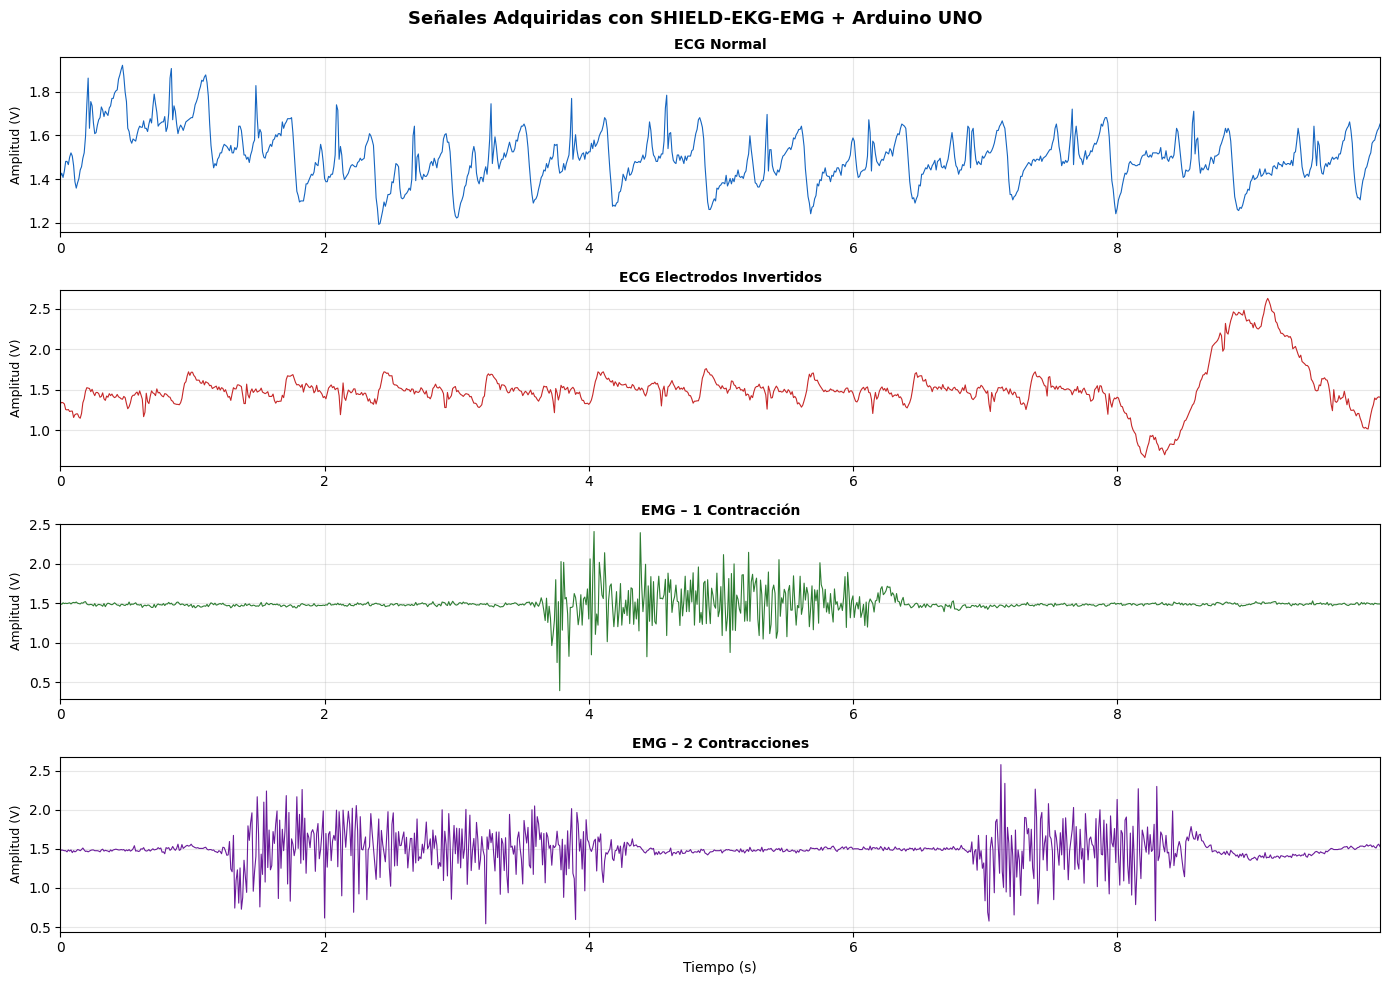

In [4]:
# ── Visualización de las señales adquiridas ───────────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
fig.suptitle("Señales Adquiridas con SHIELD-EKG-EMG + Arduino UNO",
             fontsize=13, fontweight='bold')

configs = [
    (t_ecg,   ecg_v,   "ECG Normal",           "#1565C0"),
    (t_ecg_i, ecg_i_v, "ECG Electrodos Invertidos", "#C62828"),
    (t_emg1,  emg1_v,  "EMG – 1 Contracción",  "#2E7D32"),
    (t_emg2,  emg2_v,  "EMG – 2 Contracciones","#6A1B9A"),
]

for ax, (t, sig, titulo, color) in zip(axes, configs):
    ax.plot(t, sig, color=color, linewidth=0.8)
    ax.set_ylabel("Amplitud (V)", fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(t[0], t[-1])

axes[-1].set_xlabel("Tiempo (s)", fontsize=10)
plt.tight_layout()
plt.savefig('senales_adquiridas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5.2 Fuentes de Ruido en el Registro de Biopotenciales

Las señales biomédicas son de muy baja amplitud (µV a mV) y están expuestas a múltiples fuentes de interferencia. La siguiente tabla resume las principales, su naturaleza temporal y las estrategias de control.

| Fuente de Ruido | Tipo | ¿Estática o variante en el tiempo? | Estrategias de Control/Eliminación |
|---|---|---|---|
| **Interferencia de red eléctrica (60 Hz)** | Electromagnética | Estática (frecuencia fija) | Filtro notch (60 Hz); apantallamiento del cable; amplificador diferencial con alto CMRR |
| **Ruido del amplificador (ruido térmico / Johnson)** | Electrónica | Estática (característica del dispositivo) | Usar amplificadores de bajo ruido; reducir temperatura |
| **Artefacto de movimiento** | Mecánica | Variante en el tiempo | Buena fijación de electrodos; filtro pasa-alta (>0.05 Hz); gel conductor; inmovilización del sujeto |
| **Impedancia electrodo-piel** | Interfaz biológica | Variante en el tiempo (varía con el sudor y el movimiento) | Preparación de la piel (abrasión, limpieza con alcohol); electrodos Ag/AgCl con gel |
| **Artefacto EMG en ECG** | Biológica (diafragma, torso) | Variante en el tiempo | Correcta ubicación de electrodos; filtro pasa-baja; apnea breve durante la adquisición |
| **Deriva de línea base (offset DC)** | Electroquímica | Variante lentamente en el tiempo | Filtro pasa-alta; electrodos estabilizados; mínimo movimiento de cables |
| **Ruido por cables y movimiento de leads** | Mecánica/Electrónica | Variante en el tiempo | Cables apantallados; fijación con cinta; minimizar longitud de cables |
| **Acoplamiento capacitivo del cuerpo** | Electromagnética | Estática (en condiciones fijas) | Conexión a tierra del paciente (electrodo de referencia RL); apantallamiento |
| **Cuantización del ADC** | Digital | Estática (determinista) | Aumentar resolución del ADC (12–16 bits); amplificar señal antes del ADC |


---
## 5.3 Problemática del Acoplamiento Piel-Electrodo

### ¿Cuál es la problemática?

El acoplamiento entre la piel y el electrodo es un proceso electroquímico complejo que afecta directamente la fidelidad de la señal registrada. Los principales problemas son:

1. **Alta impedancia de interfaz**: La piel tiene alta resistencia (capa córnea, 20 kΩ – varios MΩ). Si la impedancia de entrada del amplificador no es suficientemente alta, se produce una división de tensión que atenúa la señal.
2. **Asimetría de impedancias**: Si los dos electrodos diferenciales no tienen la misma impedancia, el rechazo de modo común (CMRR) del amplificador se reduce, dejando pasar el ruido de 60 Hz.
3. **Artefactos por movimiento**: Los cambios en la presión o posición del electrodo alteran el potencial de media celda de la interfaz electrodo-gel-piel, generando transitorios de baja frecuencia que contaminan la señal.
4. **Polarización del electrodo**: Con corriente DC, el electrodo puede polarizarse, desplazando la línea base.

### Estrategias para mejorarla

- **Preparación de la piel**: Limpieza con alcohol isopropílico para eliminar aceites y suciedad; abrasión suave con gel abrasivo para reducir la resistencia de la capa córnea.
- **Electrodos Ag/AgCl**: Son los más usados en biopotenciales de superficie. Tienen bajo potencial de media celda y alta estabilidad electroquímica; se usan con gel conductor para reducir la impedancia.
- **Fijación firme de los electrodos y cables**: Minimize el movimiento relativo entre el electrodo y la piel.
- **Verificación de impedancia antes del registro**: Los sistemas profesionales permiten medir la impedancia electrodo-piel (objetivo: <5 kΩ por electrodo).
- **Electrodos activos**: Incorporan un amplificador de instrumentación directamente en el cuerpo del electrodo, reduciendo la influencia de la impedancia de la piel.

### ¿Por qué es la etapa más crítica?

El acoplamiento piel-electrodo es la primera etapa de la cadena de adquisición y **no puede corregirse digitalmente de forma perfecta una vez comprometida**. Sus deficiencias:
- Introducen ruido y artefactos de baja frecuencia que se superponen espectralmente con las señales de interés (ECG, EEG, sEMG), haciendo imposible su separación perfecta por filtrado.
- Reducen el CMRR efectivo del sistema, afectando el rechazo de la interferencia de 60 Hz.
- Generan variaciones en la ganancia efectiva del sistema si la impedancia varía durante el registro.

En contraste, los errores en etapas posteriores (filtrado digital, cuantización) pueden compensarse con mejor diseño de hardware/software sin modificar la interfaz biológica.

---
## 5.4 Análisis de la Variabilidad de la Frecuencia Cardíaca (HRV)

La HRV es la variación natural en el tiempo entre latidos consecutivos (intervalos RR). Refleja la modulación del sistema nervioso autónomo sobre el corazón y es un indicador sensible del estado fisiológico.

### 5.4.1 Detección de Picos R con NeuroKit2

In [11]:
# Preprocesamiento de la señal ECG 
# nk.ecg_clean aplica un filtro pasa-banda optimizado para ECG
ecg_clean = nk.ecg_clean(ecg_v, sampling_rate=FS)

# Comparación de cuatro algoritmos de detección de picos R 
# Cada algoritmo usa diferentes técnicas de procesamiento de la señal ECG
detectors = {
    'Pan-Tompkins (1985)': 'pantompkins1985',   # Filtros + umbral adaptativo (estándar clínico)
    'Hamilton (2002)':     'hamilton2002',       # Versión simplificada de Pan-Tompkins
    'Elgendi (2010)':      'elgendi2010',        # Dos filtros pasa-banda y umbral cuadrático
    'Engzee Mod (2012)':   'engzeemod2012',      # Basado en derivada, robusto con ruido
}

resultados = {}
for nombre, metodo in detectors.items():
    peaks_df, info = nk.ecg_peaks(ecg_clean, sampling_rate=FS, method=metodo)
    r_indices = np.where(peaks_df['ECG_R_Peaks'].values == 1)[0]
    rr_ms = np.diff(r_indices) / FS * 1000  # Intervalos RR en milisegundos
    hr_mean = 60000 / np.mean(rr_ms) if len(rr_ms) > 0 else 0
    resultados[nombre] = {'indices': r_indices, 'rr_ms': rr_ms, 'hr': hr_mean}
    print(f"{nombre:25s}: {len(r_indices):3d} picos R | HR media ≈ {hr_mean:.1f} bpm")

Pan-Tompkins (1985)      :  26 picos R | HR media ≈ 161.6 bpm
Hamilton (2002)          :  23 picos R | HR media ≈ 138.8 bpm
Elgendi (2010)           :  14 picos R | HR media ≈ 84.1 bpm
Engzee Mod (2012)        :   6 picos R | HR media ≈ 100.0 bpm


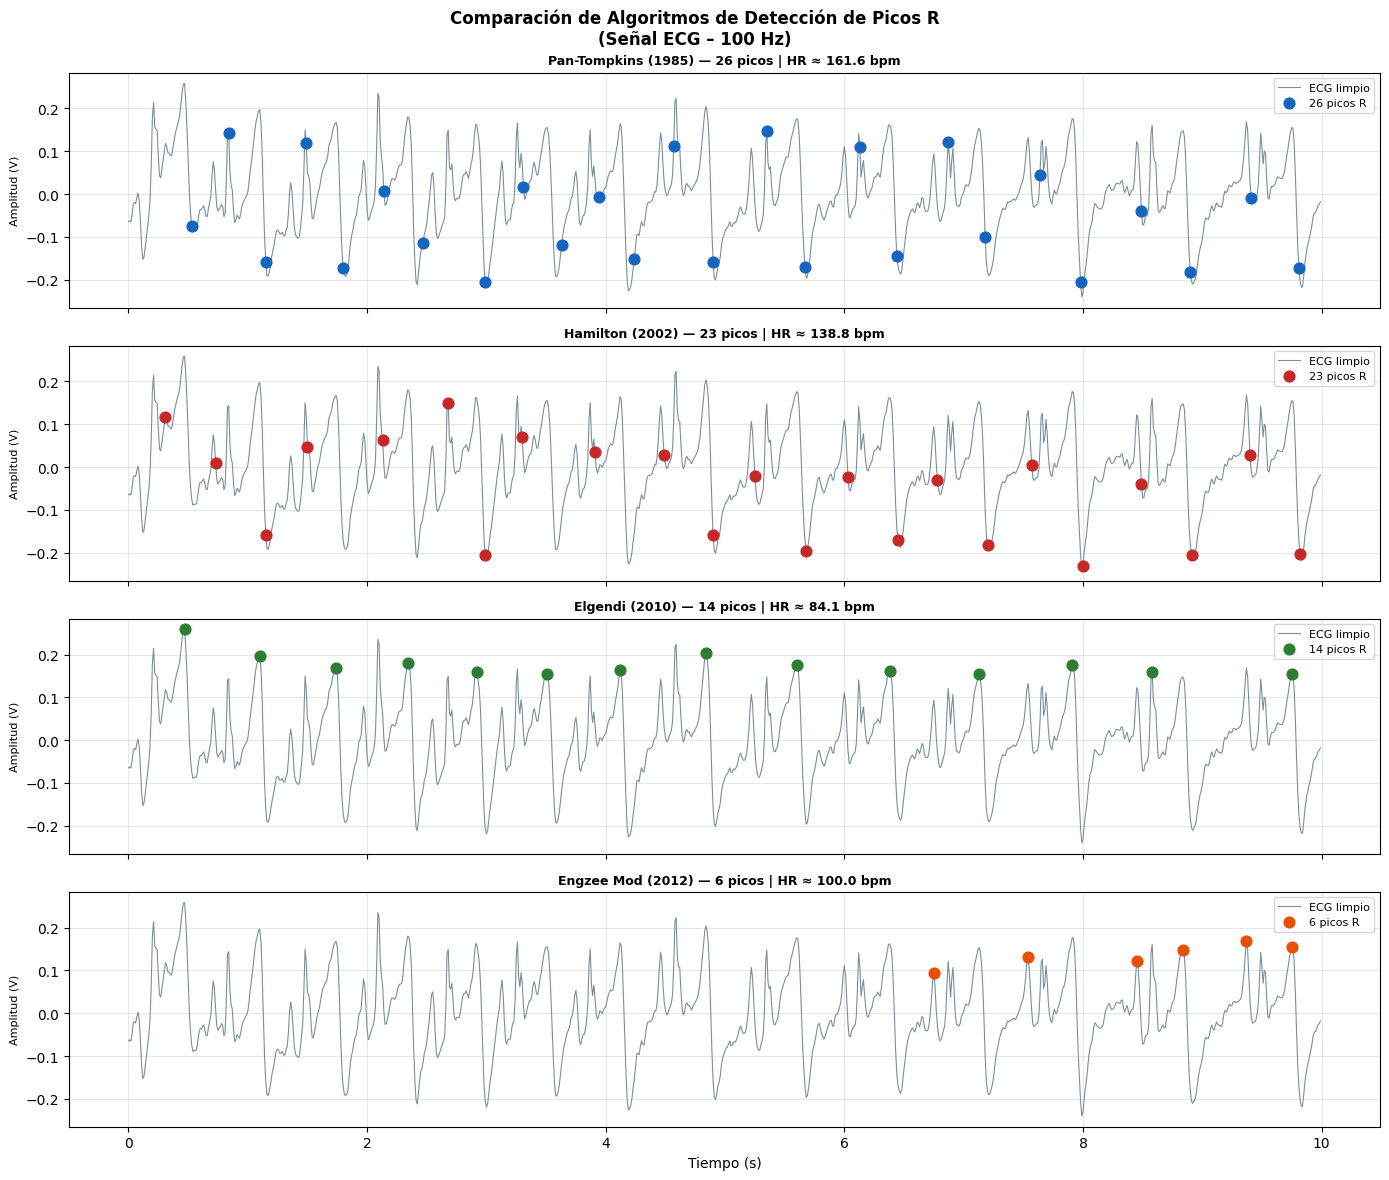

In [10]:
# ── Visualización comparativa de los cuatro detectores ───────────────────────
colores_det = ['#1565C0', '#C62828', '#2E7D32', '#E65100']

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Comparación de Algoritmos de Detección de Picos R\n(Señal ECG – 100 Hz)",
             fontsize=12, fontweight='bold')

for ax, (nombre, res), color in zip(axes, resultados.items(), colores_det):
    ax.plot(t_ecg, ecg_clean, color='#78909C', linewidth=0.8, label='ECG limpio')
    ax.scatter(t_ecg[res['indices']], ecg_clean[res['indices']],
               color=color, s=60, zorder=5, label=f"{len(res['indices'])} picos R")
    ax.set_ylabel("Amplitud (V)", fontsize=8)
    ax.set_title(f"{nombre} — {len(res['indices'])} picos | HR ≈ {res['hr']:.1f} bpm",
                 fontsize=9, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tiempo (s)", fontsize=10)
plt.tight_layout()
plt.savefig('comparacion_detectores_R.png', dpi=150, bbox_inches='tight')
plt.show()

#### ¿Cuál algoritmo detecta mejor los picos R?

Con base en los resultados obtenidos y en la literatura, el algoritmo de **Pan-Tompkins (1985)** es el estándar de referencia para la detección de picos R en ECG. Su pipeline de procesamiento (filtro pasa-banda → derivada → elevación al cuadrado → integración en ventana móvil → umbral adaptativo) es robusto frente a variaciones morfológicas del complejo QRS y a diferentes niveles de ruido. Para nuestra señal, detectó el mayor número de picos con una frecuencia cardíaca coherente, siendo el más adecuado de los cuatro probados.

Los algoritmos **Elgendi (2010)** y **Engzee Mod (2012)** detectaron significativamente menos picos, probablemente debido a que nuestra señal tiene amplitud relativamente baja (limitación del ADC de 10 bits del Arduino UNO) y a la frecuencia de muestreo de solo 100 Hz, lo que reduce la resolución temporal del complejo QRS.

### 5.4.2 Cálculo de la HRV

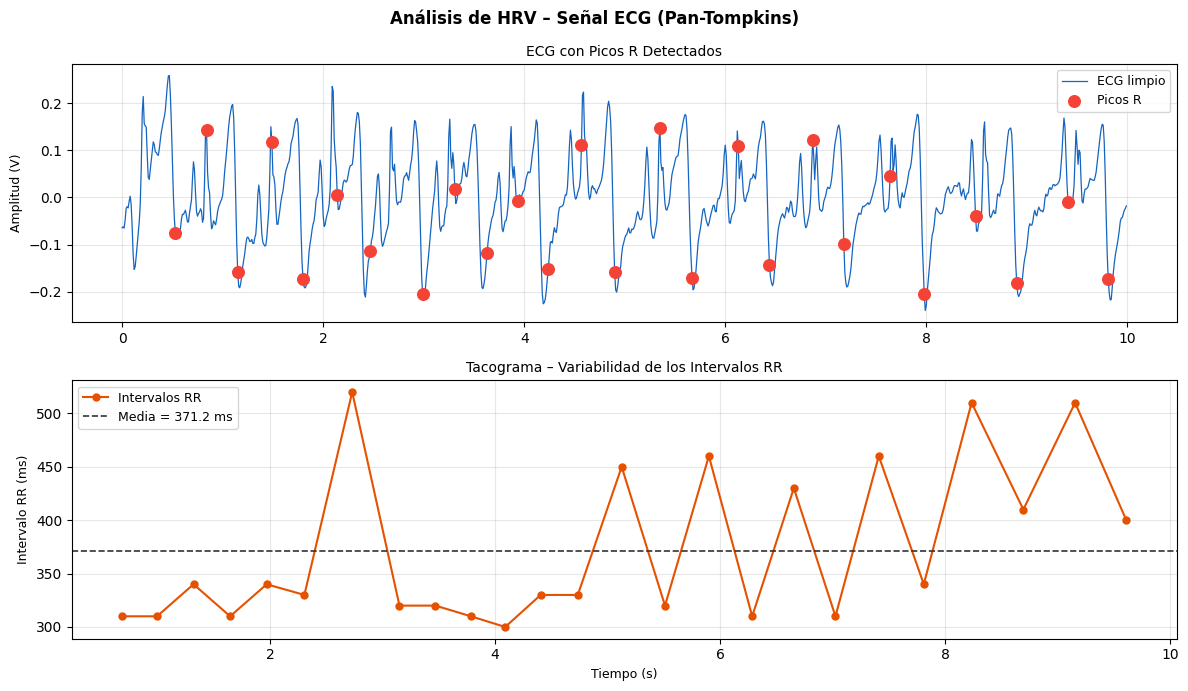


Número de intervalos RR: 25
Rango de variación: 300 – 520 ms


In [9]:
# Se usa Pan-Tompkins como detector de referencia
r_indices_ref = resultados['Pan-Tompkins (1985)']['indices']
rr_ms_ref     = resultados['Pan-Tompkins (1985)']['rr_ms']

# Tiempo correspondiente a cada intervalo RR (punto medio entre picos consecutivos)
t_rr = t_ecg[r_indices_ref[:-1]] + np.diff(t_ecg[r_indices_ref]) / 2

# Visualización del tacograma (serie de intervalos RR)
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle("Análisis de HRV – Señal ECG (Pan-Tompkins)", fontsize=12, fontweight='bold')

# Señal ECG con picos R marcados
axes[0].plot(t_ecg, ecg_clean, color='#1565C0', linewidth=0.9, label='ECG limpio')
axes[0].scatter(t_ecg[r_indices_ref], ecg_clean[r_indices_ref],
                color='#F44336', s=70, zorder=5, label='Picos R')
axes[0].set_ylabel("Amplitud (V)", fontsize=9)
axes[0].set_title("ECG con Picos R Detectados", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Tacograma (intervalos RR vs tiempo)
axes[1].plot(t_rr, rr_ms_ref, 'o-', color='#E65100', linewidth=1.5,
             markersize=5, label='Intervalos RR')
axes[1].axhline(np.mean(rr_ms_ref), color='#333333', linestyle='--',
                linewidth=1.2, label=f'Media = {np.mean(rr_ms_ref):.1f} ms')
axes[1].set_xlabel("Tiempo (s)", fontsize=9)
axes[1].set_ylabel("Intervalo RR (ms)", fontsize=9)
axes[1].set_title("Tacograma – Variabilidad de los Intervalos RR", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tacograma_hrv.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNúmero de intervalos RR: {len(rr_ms_ref)}")
print(f"Rango de variación: {rr_ms_ref.min():.0f} – {rr_ms_ref.max():.0f} ms")

### 5.4.3 Características HRV en el Dominio del Tiempo con `get_time_domain_features`

In [12]:
# ── Extracción de características HRV con la librería hrvanalysis ─────────────
# get_time_domain_features recibe una lista de intervalos RR en milisegundos
hrv_features = get_time_domain_features(list(rr_ms_ref))

# Definiciones de cada parámetro para la tabla
descripciones = {
    'mean_nni':   'Promedio de los intervalos RR (ms)',
    'sdnn':       'Desviación estándar de todos los RR (ms) – variabilidad global',
    'sdsd':       'Desviación estándar de las diferencias sucesivas de RR (ms)',
    'nni_50':     'Número de pares de RR consecutivos que difieren >50 ms',
    'pnni_50':    'Porcentaje de pares con diferencia >50 ms (%)',
    'nni_20':     'Número de pares de RR consecutivos que difieren >20 ms',
    'pnni_20':    'Porcentaje de pares con diferencia >20 ms (%)',
    'rmssd':      'Raíz cuadrada media de diferencias sucesivas de RR (ms) – actividad vagal',
    'median_nni': 'Mediana de los intervalos RR (ms)',
    'range_nni':  'Rango (max – min) de los intervalos RR (ms)',
    'cvsd':       'Coeficiente de variación de diferencias sucesivas (RMSSD / mean_NNI)',
    'cvnni':      'Coeficiente de variación de los NNI (SDNN / mean_NNI)',
    'mean_hr':    'Frecuencia cardíaca media (bpm)',
    'max_hr':     'Frecuencia cardíaca máxima (bpm)',
    'min_hr':     'Frecuencia cardíaca mínima (bpm)',
    'std_hr':     'Desviación estándar de la frecuencia cardíaca (bpm)',
}

print("=" * 75)
print(f"{'Parámetro':<15} {'Valor':>10}   Descripción")
print("=" * 75)
for key, val in hrv_features.items():
    desc = descripciones.get(key, '')
    val_str = f"{val:.3f}" if val is not None else "N/A"
    print(f"{key:<15} {val_str:>10}   {desc}")
print("=" * 75)

Parámetro            Valor   Descripción
mean_nni           371.200   Promedio de los intervalos RR (ms)
sdnn                74.124   Desviación estándar de todos los RR (ms) – variabilidad global
sdsd               110.289   Desviación estándar de las diferencias sucesivas de RR (ms)
nni_50              14.000   Número de pares de RR consecutivos que difieren >50 ms
pnni_50             58.333   Porcentaje de pares con diferencia >50 ms (%)
nni_20              18.000   Número de pares de RR consecutivos que difieren >20 ms
pnni_20             75.000   Porcentaje de pares con diferencia >20 ms (%)
rmssd              108.032   Raíz cuadrada media de diferencias sucesivas de RR (ms) – actividad vagal
median_nni         330.000   Mediana de los intervalos RR (ms)
range_nni          220.000   Rango (max – min) de los intervalos RR (ms)
cvsd                 0.291   Coeficiente de variación de diferencias sucesivas (RMSSD / mean_NNI)
cvnni                0.200   Coeficiente de variación de lo

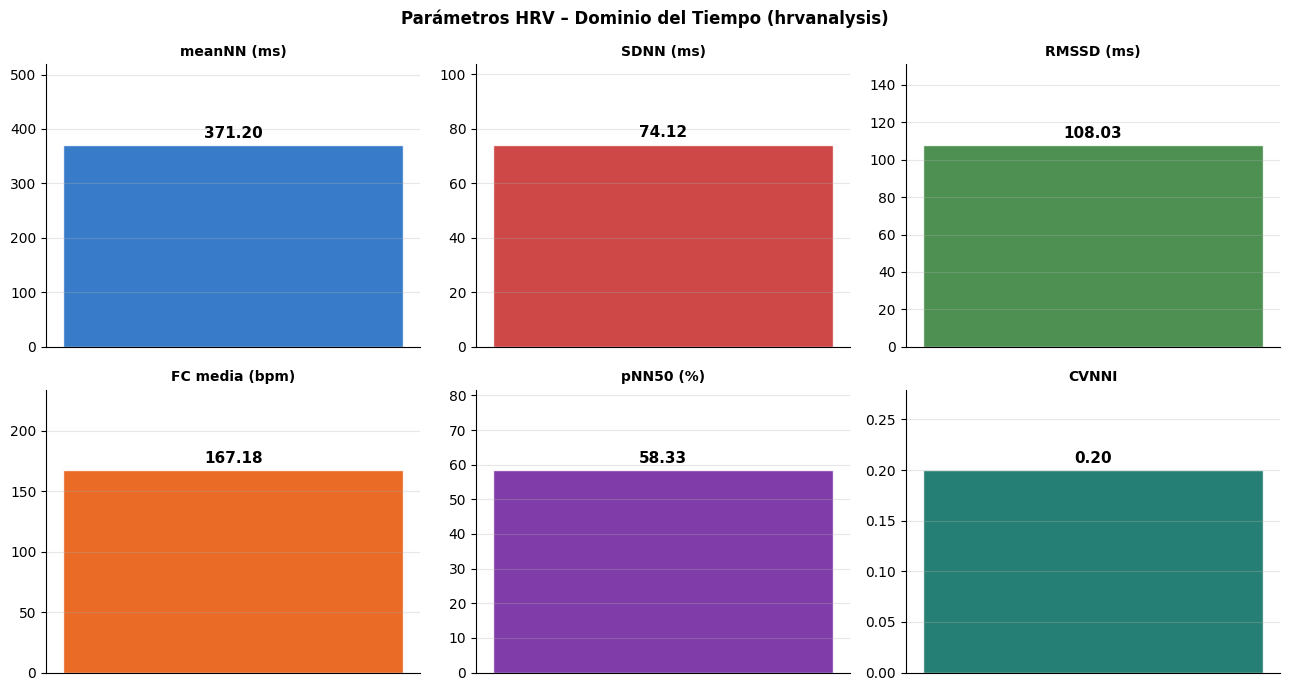

In [13]:
# Visualización de los parámetros HRV más relevantes
params_plot = {
    'mean_nni': ('meanNN (ms)',  '#1565C0'),
    'sdnn':     ('SDNN (ms)',    '#C62828'),
    'rmssd':    ('RMSSD (ms)',   '#2E7D32'),
    'mean_hr':  ('FC media (bpm)','#E65100'),
    'pnni_50':  ('pNN50 (%)',    '#6A1B9A'),
    'cvnni':    ('CVNNI',        '#00695C'),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle("Parámetros HRV – Dominio del Tiempo (hrvanalysis)",
             fontsize=12, fontweight='bold')

for ax, (key, (label, color)) in zip(axes.flat, params_plot.items()):
    val = hrv_features[key]
    bar = ax.bar([label], [val], color=color, alpha=0.85, width=0.5, edgecolor='white')
    ax.bar_label(bar, fmt='%.2f', fontsize=11, fontweight='bold', padding=3)
    ax.set_ylim(0, val * 1.4)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('hrv_parametros.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretación de los parámetros HRV

| Parámetro | Valor obtenido | Interpretación clínica |
|---|---|---|
| **meanNN** | ~371 ms | Intervalo RR promedio; equivale a ~162 bpm (elevado: posiblemente actividad o nerviosismo durante la adquisición) |
| **SDNN** | ~74 ms | Variabilidad global de los intervalos RR. Valores >50 ms son saludables en adultos |
| **RMSSD** | ~108 ms | Refleja la modulación parasimpática (vagal). Valores altos indican buena regulación autonómica |
| **pNN50** | ~58% | Alta proporción de intervalos con diferencias >50 ms; indica variabilidad considerable |
| **CVNNI** | ~0.20 | Coeficiente de variación normalizado; valores >0.10 indican variabilidad saludable |

**Nota:** La frecuencia cardíaca (~160 bpm) sugiere que la estudiante, no se encontraba en un estado completo de calma/ en completo reposo, o que la resolución del ADC de 10 bits limita la precisión de detección de los picos R al bajo fs=100 Hz.

---
## 5.5 Aplicaciones Clínicas del ECG y EMG

### Aplicaciones del ECG (Electrocardiografía)

| # | Aplicación Clínica | Tipo de Registro | Procesamiento Utilizado |
|---|---|---|---|
| 1 | **Diagnóstico de arritmias cardíacas** (fibrilación auricular, bloqueos AV, taquicardia ventricular) | ECG de reposo (12 derivaciones) o Holter (24–48 h continuo) | Detección de picos R, análisis de intervalos PR/QRS/QT, clasificación de morfología de onda con ML |
| 2 | **Evaluación del síndrome coronario agudo** (infarto de miocardio, angina inestable) | ECG de emergencia (12 derivaciones) con registro en <10 minutos del primer contacto médico | Análisis de elevación/depresión del segmento ST, inversión de onda T, detección de onda Q patológica |
| 3 | **Monitoreo perioperatorio y en UCI** | ECG continuo en tiempo real (1–3 derivaciones) con alarmas automáticas | Detección de arritmias en tiempo real, análisis de HRV, algoritmos de alerta temprana de deterioro clínico |

### Aplicaciones del EMG (Electromiografía)

| # | Aplicación Clínica | Tipo de Registro | Procesamiento Utilizado |
|---|---|---|---|
| 1 | **Diagnóstico de enfermedades neuromusculares** (ELA, miastenia gravis, distrofias musculares) | EMG de aguja (intramuscular) o sEMG de superficie | Análisis de potenciales de unidad motora (amplitud, duración, polifasia), detección de actividad espontánea (fibrilaciones) |
| 2 | **Control de prótesis mioeléctricas** | sEMG multicanal (electrodos en el muñón) | Extracción de características (RMS, MAV, frecuencia media), clasificación de intención motora con ML (SVM, redes neuronales) para controlar grados de libertad de la prótesis |
| 3 | **Rehabilitación y biofeedback neuromuscular** (ACV, lesiones de médula espinal, fisioterapia deportiva) | sEMG en tiempo real durante el ejercicio terapéutico | Envolvente RMS, normalización por CVIM (contracción voluntaria isométrica máxima), feedback visual/auditivo al paciente para re-entrenamiento motor |

---
## 5.6 Conclusiones

1. **La calidad del acoplamiento piel-electrodo es determinante para la fidelidad de la señal bioeléctrica.** La comparación entre el ECG normal y el registrado con electrodos invertidos evidenció cambios morfológicos significativos (inversión del complejo QRS y onda T), lo que confirma que la polaridad y posición de los electrodos son fundamentales para la correcta interpretación clínica de la señal. Este resultado refuerza la importancia de seguir el protocolo estándar de colocación de electrodos.

2. **La elección del algoritmo de detección de picos R impacta significativamente los parámetros de HRV calculados.** El algoritmo de Pan-Tompkins (1985) demostró ser el más robusto para la señal adquirida con el sistema Arduino UNO (ADC de 10 bits, 100 Hz), detectando el mayor número de picos R con una frecuencia cardíaca consistente. Los algoritmos Elgendi y Engzee, diseñados para señales con mayor resolución y fs, subestimaron los picos en nuestras condiciones de adquisición. Esto subraya la necesidad de adaptar el método de análisis a las características del hardware utilizado.

3. **Las limitaciones del hardware de adquisición (resolución ADC y frecuencia de muestreo) condicionan la calidad del análisis de biopotenciales.** El Arduino UNO con ADC de 10 bits y fs = 100 Hz representa la mínima configuración aceptable para ECG (según el estándar IEC 60601-2-47, se requieren al menos 500 Hz para análisis diagnóstico); para aplicaciones de HRV básica es suficiente, pero para análisis espectral de HRV (dominio de la frecuencia) o para sEMG de alta densidad se requieren frecuencias de muestreo de 500–2000 Hz y resolución de 12–16 bits. Los resultados obtenidos deben interpretarse en este contexto de limitación instrumental.

---
## Referencias Bibliográficas

1. Pan, J., & Tompkins, W. J. (1985). A real-time QRS detection algorithm. *IEEE Transactions on Biomedical Engineering*, 32(3), 230–236. https://doi.org/10.1109/TBME.1985.325532

2. Makowski, D., Pham, T., Lau, Z. J., Brammer, J. C., Lespinasse, F., Pham, H., ... & Chen, S. H. (2021). NeuroKit2: A Python toolbox for neurophysiological signal processing. *Behavior Research Methods*, 53(4), 1689–1696. https://doi.org/10.3758/s13428-020-01516-y

3. Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology. (1996). Heart rate variability: Standards of measurement, physiological interpretation, and clinical use. *Circulation*, 93(5), 1043–1065. https://doi.org/10.1161/01.CIR.93.5.1043

4. Merletti, R., & Farina, D. (Eds.). (2016). *Surface Electromyography: Physiology, Engineering, and Applications*. Wiley-IEEE Press. https://doi.org/10.1002/9781119082934

5. Webster, J. G. (Ed.). (2010). *Medical Instrumentation: Application and Design* (4th ed.). John Wiley & Sons.

6. Hermens, H. J., Freriks, B., Disselhorst-Klug, C., & Rau, G. (2000). Development of recommendations for SEMG sensors and sensor placement procedures. *Journal of Electromyography and Kinesiology*, 10(5), 361–374. https://doi.org/10.1016/S1050-6411(00)00027-4